In [1]:
import numpy as np
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt

import lightgbm
import xgboost
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.base import clone
from sklearn.model_selection import KFold, train_test_split

import shap
import optuna
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
MAE = lambda y_true, y_pred: np.mean(np.abs(y_true - y_pred))

In [3]:
train = pd.read_csv("/kaggle/input/notebooks/khoatran311/analyzing-nonlinearities-with-gam/train_new.csv")
test  = pd.read_csv("/kaggle/input/notebooks/khoatran311/analyzing-nonlinearities-with-gam/test_new.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/the-perfect-fit/sample_submission.csv")

In [4]:
def add_fourier_features(df, col, K=5):
    x = df[col]
    x_scaled = 2 * np.pi * (x - x.min()) / (x.max() - x.min())
    for k in range(1, K+1):
        df[f"{col}_sin_{k}"] = np.sin(k * x_scaled)
        df[f"{col}_cos_{k}"] = np.cos(k * x_scaled)
        
def make_features(df):
    df_copy = df.copy()
    ## Handle outliers in x5
    df_copy.loc[df_copy["x5"]==999, "x5"] = np.nan
    ## Product of x10 and x11
    df_copy["x10_11_prod"] = df["x10"]*df["x11"]
    ## Fourier features for x2
    add_fourier_features(df_copy, "x2")
    return df_copy

In [5]:
train_new = make_features(train)

X = train_new.copy()
y = X.pop("target")

In [6]:
def cross_validate(model, model_type, X, y, scorer=MAE, n_splits=5, seed=3126):
    kfold  = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = np.zeros(n_splits) 

    for i,(train_idx,val_idx) in enumerate(kfold.split(X)):
        ## Splits data
        X_train, y_train = X.iloc[train_idx,:], y[train_idx]
        X_val,   y_val   = X.iloc[val_idx,:],   y[val_idx]

        cloned_model = clone(model)
        ## Fits model
        if model_type=="lgbm":
            cloned_model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric="mae",
                callbacks=[lightgbm.early_stopping(100, verbose=False)])
      
        elif model_type=="xgboost":
            cloned_model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)], verbose=False)
            
        else: 
            cloned_model.fit(X_train, y_train)

        ## Stores the score
        scores[i] = scorer(y_val, cloned_model.predict(X_val))
    return scores

# Evaluating LGBMRegressor [4.84 leaderboard MAE]

In [7]:
# def objective(trial):
#     params = {
#         "min_split_loss":trial.suggest_float("min_split_loss", .00001, 1, log=True),
#         "min_child_weight":trial.suggest_float("min_child_weight", .00001, 1, log=True),
#         "learning_rate":trial.suggest_float("learning_rate", .005, .3, log=True),
#         "reg_alpha":trial.suggest_float("reg_alpha", .0001, 2, log=True),
#         "reg_lambda":trial.suggest_float("reg_lambda", .0001, 2, log=True),
#         "colsample_bytree":trial.suggest_float("colsample_bytree", .5, 1.0),
#         "subsample":trial.suggest_float("subsample", .5, 1.0),
#         "min_child_samples":trial.suggest_int("min_child_samples", 20, 250),
#         "huber_slope":trial.suggest_float("huber_slope", .1, 2, log=True)
#     }
#     params["n_estimators"] = 3000
#     params["max_depth"]    = 2
#     params["n_jobs"]       = -1
#     params["random_state"] = 3126
#     params["objective"]    = "reg:pseudohubererror"
#     params["early_stopping_rounds"] = 100
#     params["eval_metric"]  = "mae"
#     params["verbosity"]    = 0
    
#     model  = XGBRegressor(**params)
#     scores = cross_validate(model, "xgboost", X, y)
#     return np.mean(scores)

# study = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=3126),
# )
# study.optimize(objective, n_trials=200)

In [8]:
# params = {
#     'n_estimators': 2670, 
#     'max_depth': 2, 
#     'min_split_loss': 0.023248741888107827, 
#     'min_child_weight': 4.500578375526713e-05, 
#     'learning_rate': 0.034071029408158385, 
#     'reg_alpha': 0.013360495693441554, 
#     'reg_lambda': 1.2922820693969224, 
#     'colsample_bytree': 0.9203003240503519, 
#     'subsample': 0.5474896991519321, 
#     'min_child_samples': 235, 
#     'huber_slope': 0.26736193963438926, 
#     'max_leaves': 4
# }
# params["objective"]   = "reg:pseudohubererror"
# params["eval_metric"] = "mae"
# params["early_stopping_rounds"] = 100
# params["n_jobs"] = -1
# params["random_state"] = 3126
# params["verbosity"] = 0

# model  = XGBRegressor(**params)
# scores = cross_validate(model, "xgboost", X, y)
# print(f"Mean MAE Score: {np.mean(scores):.3f}")
# print(f"SD MAE Score: {np.std(scores):.3f}")

In [9]:
params = {
    'min_split_loss': 0.0009747428596387491, 
    'min_child_weight': 0.0007252597309807894, 
    'learning_rate': 0.038824907138762486, 
    'reg_alpha': 0.7272645747279445, 
    'reg_lambda': 1.4767087892831248, 
    'colsample_bytree': 0.5912732175055782, 
    'subsample': 0.5168901031281665, 
    'min_child_samples': 142, 
    'huber_slope': 0.35193164590208625
}
params["n_estimators"] = 3000
params["max_depth"]    = 2
params["n_jobs"]       = -1
params["random_state"] = 3126
params["objective"]    = "reg:pseudohubererror"
params["early_stopping_rounds"] = 100
params["eval_metric"]  = "mae"
params["verbosity"]    = 0

model  = XGBRegressor(**params)

for k in range(10):
    print(f"Iteration {k+1}")
    scores = cross_validate(model, "xgboost", X, y, seed=k*3126)
    print(f"Mean MAE Score: {np.mean(scores):.3f}")
    print(f"SD MAE Score: {np.std(scores):.3f}")
    print()

Iteration 1
Mean MAE Score: 3.133
SD MAE Score: 0.294

Iteration 2
Mean MAE Score: 3.134
SD MAE Score: 0.209

Iteration 3
Mean MAE Score: 3.145
SD MAE Score: 0.188

Iteration 4
Mean MAE Score: 3.144
SD MAE Score: 0.257

Iteration 5
Mean MAE Score: 3.191
SD MAE Score: 0.117

Iteration 6
Mean MAE Score: 3.207
SD MAE Score: 0.094

Iteration 7
Mean MAE Score: 3.111
SD MAE Score: 0.213

Iteration 8
Mean MAE Score: 3.179
SD MAE Score: 0.184

Iteration 9
Mean MAE Score: 3.148
SD MAE Score: 0.298

Iteration 10
Mean MAE Score: 3.158
SD MAE Score: 0.140



In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.3, shuffle=True, random_state=3126)
model = XGBRegressor(**params)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5912732175055782, device=None,
             early_stopping_rounds=100, enable_categorical=False,
             eval_metric='mae', feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, huber_slope=0.35193164590208625,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.038824907138762486, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_samples=142, min_child_weight=0.0007252597309807894,
             min_split_loss=0.0009747428596387491, missing=nan,
             monotone_constraints=None, multi_strategy=None, ...)

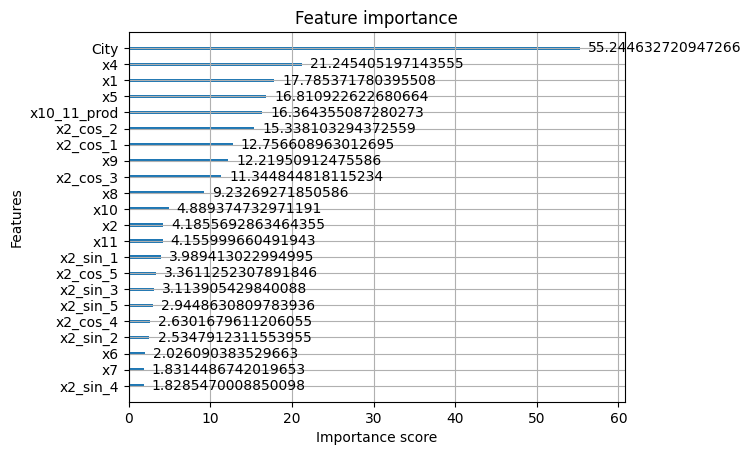

In [11]:
xgboost.plot_importance(model, importance_type="gain")
plt.show()

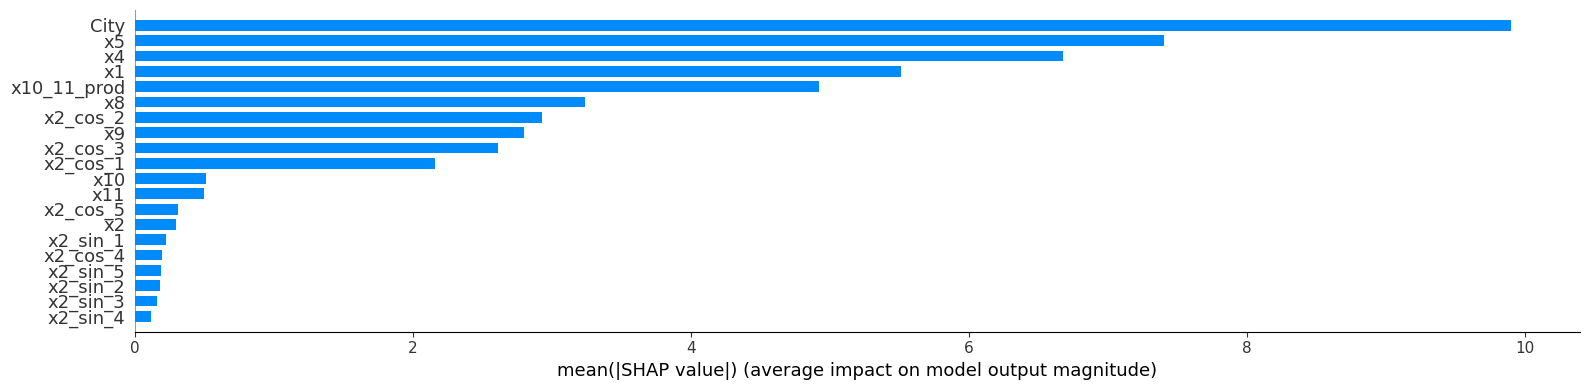

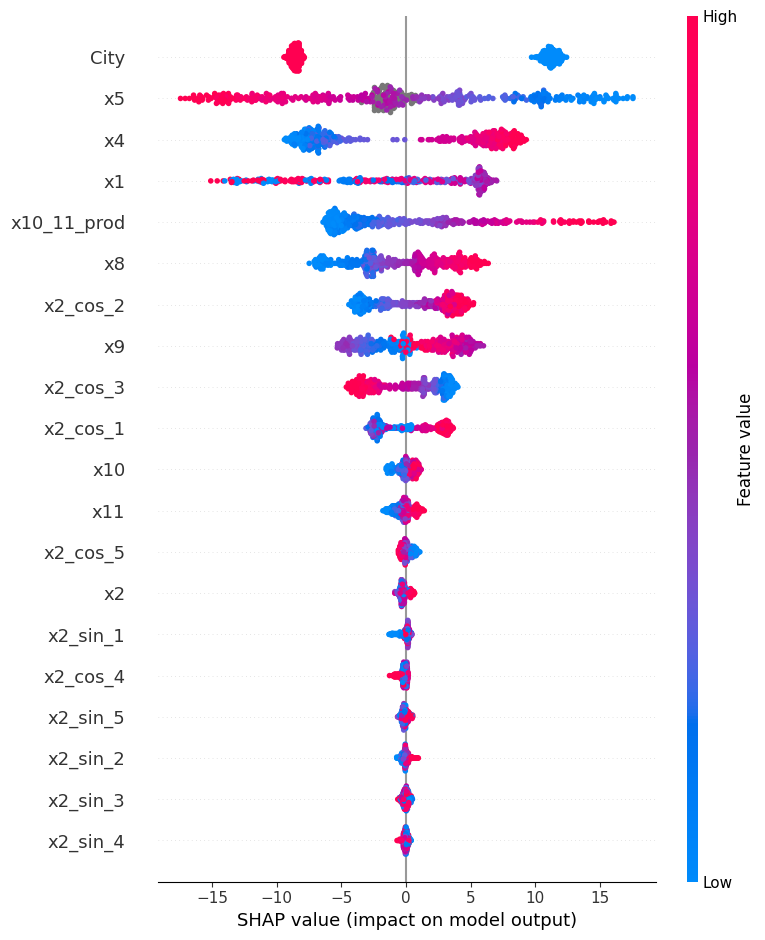

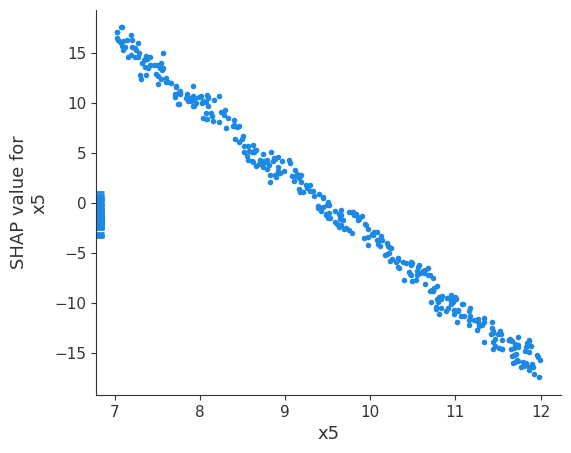

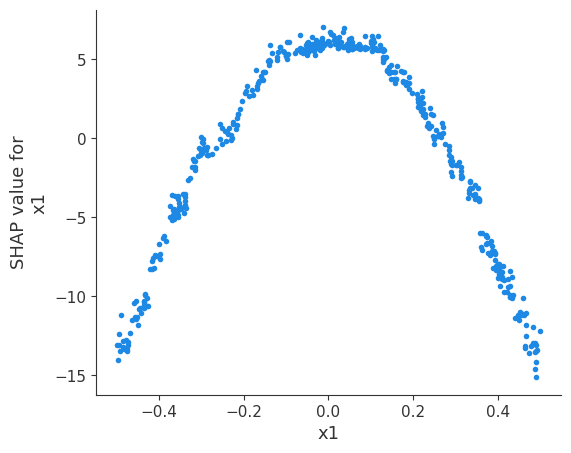

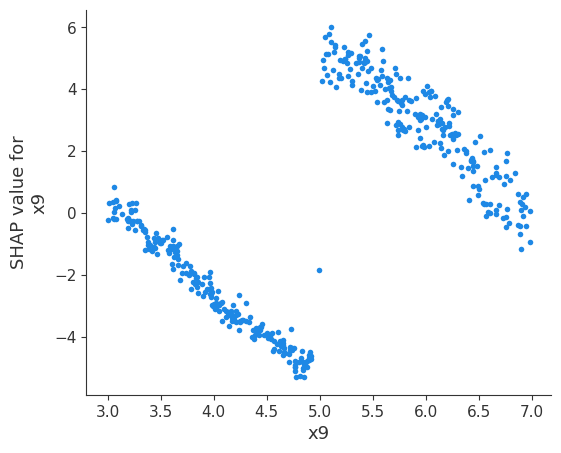

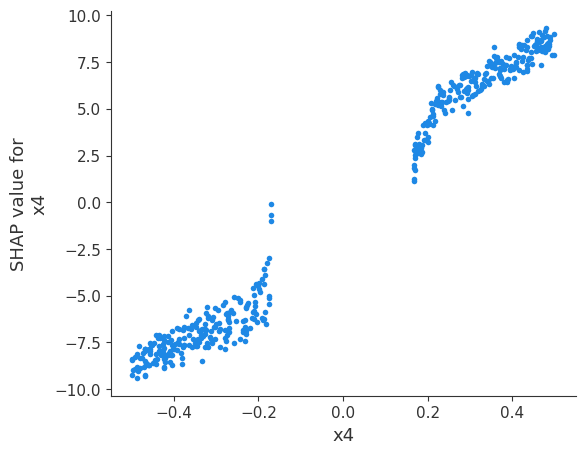

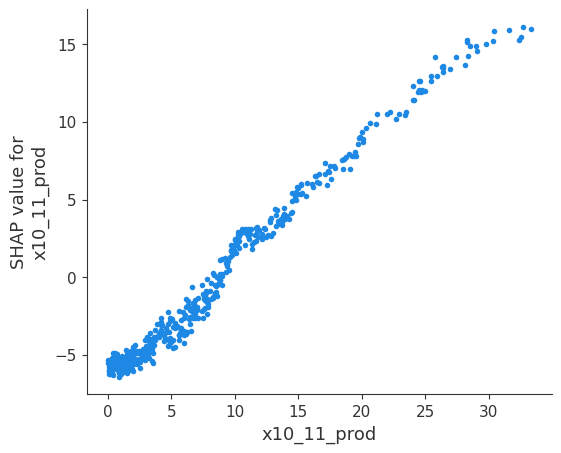

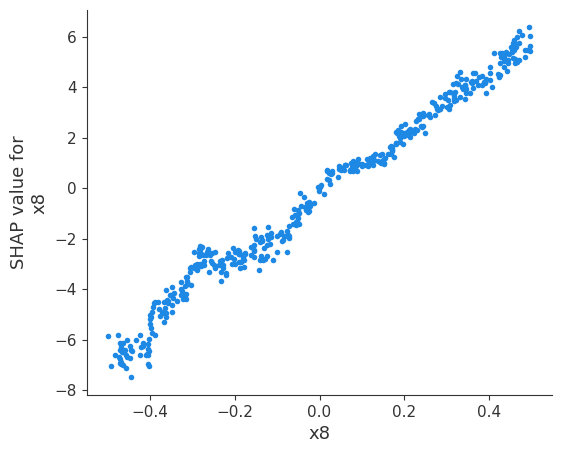

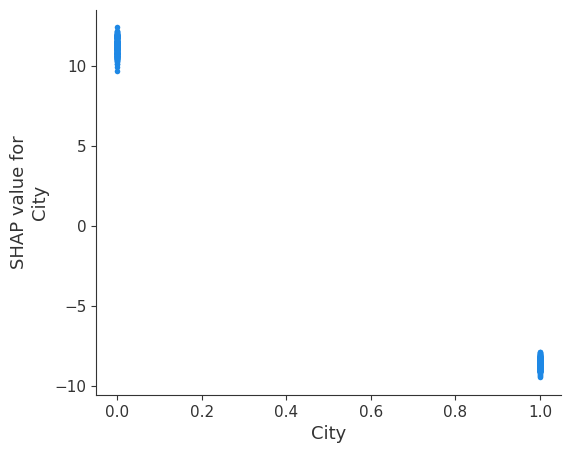

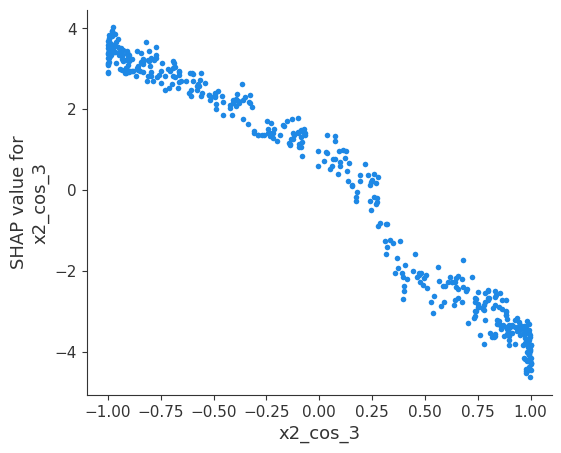

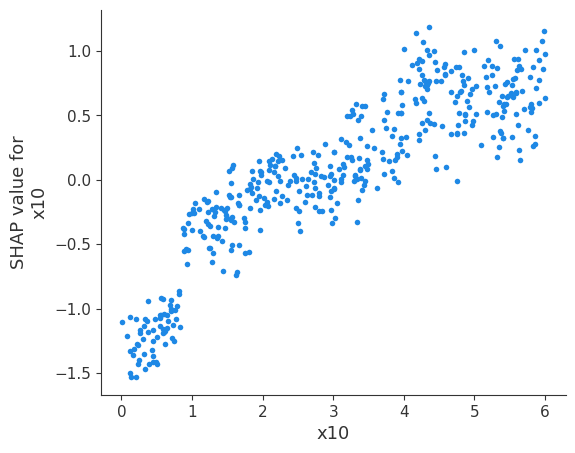

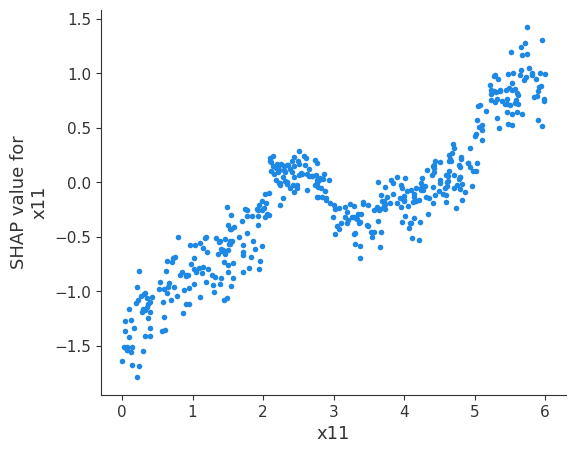

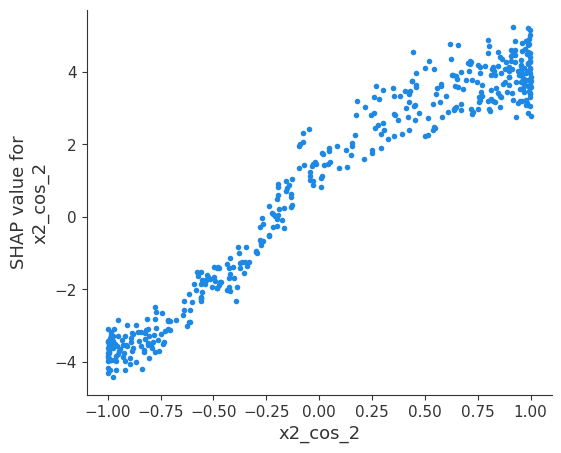

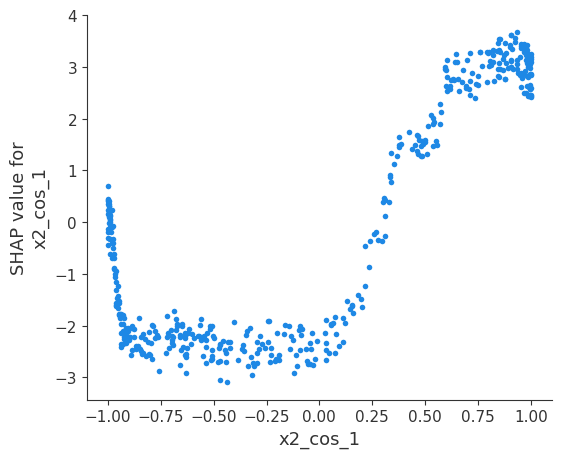

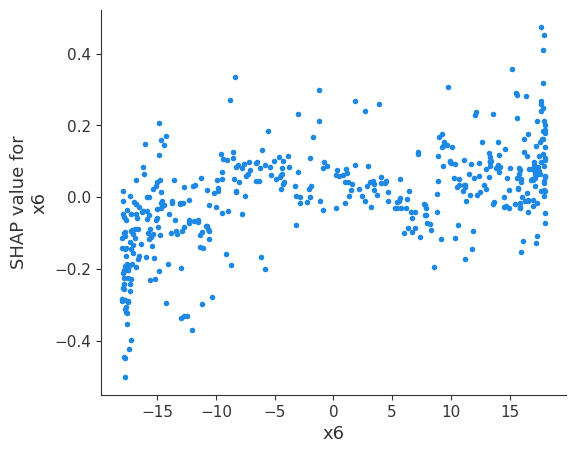

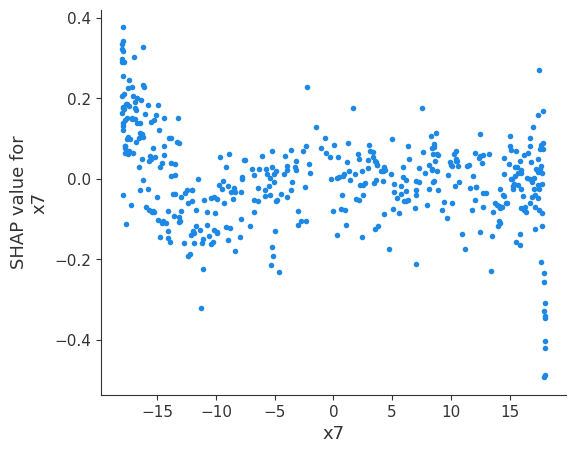

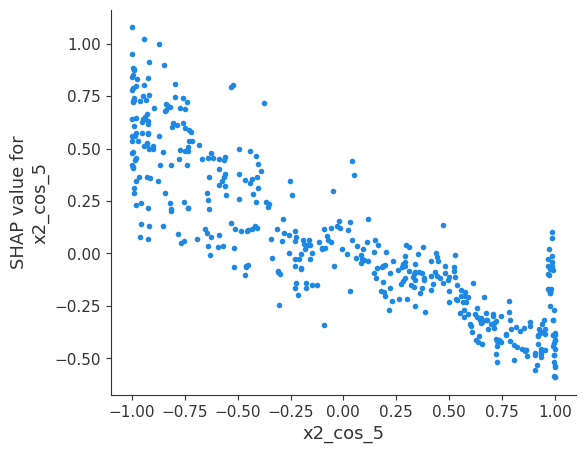

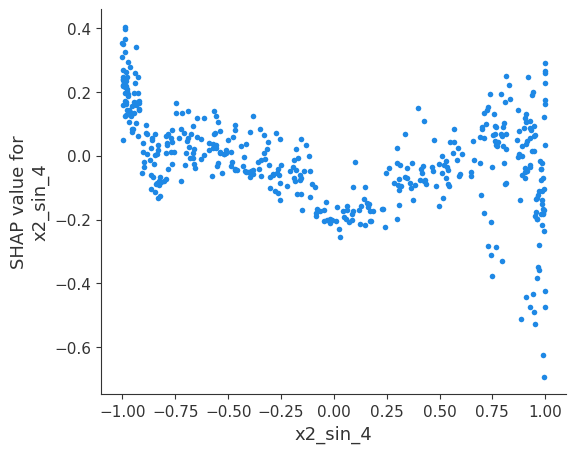

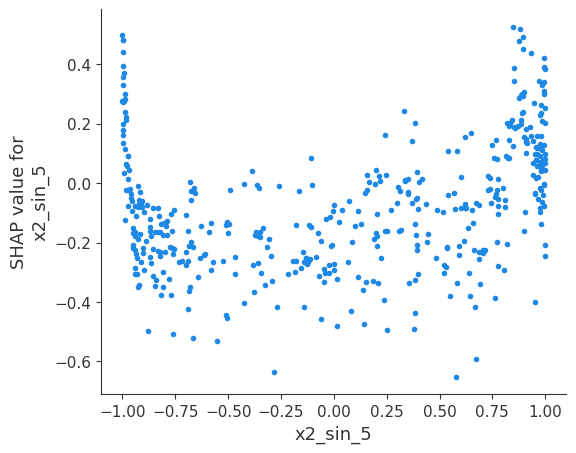

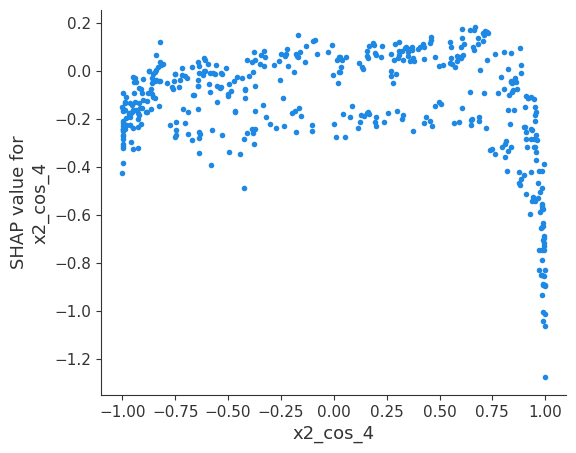

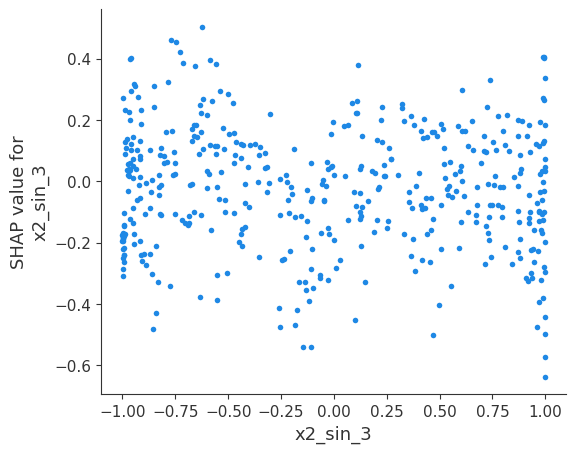

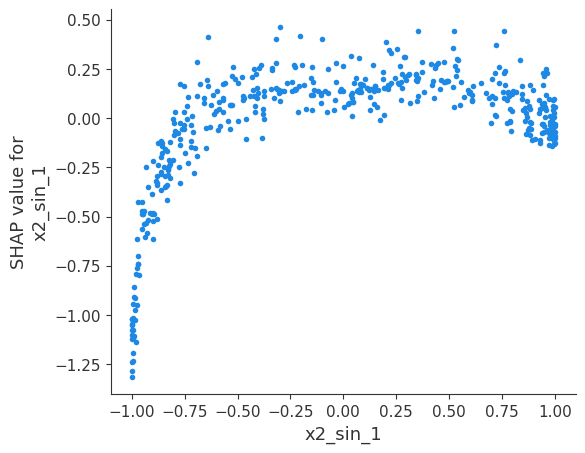

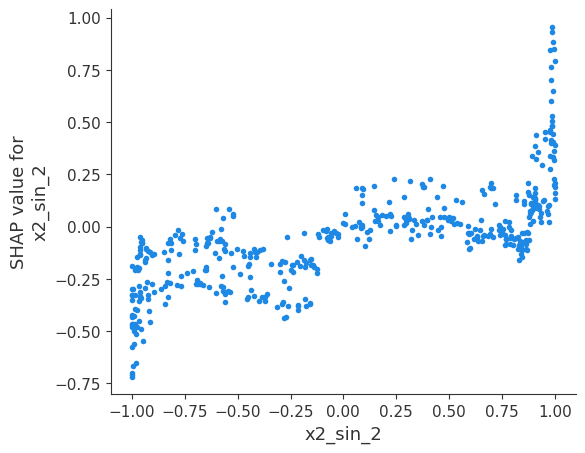

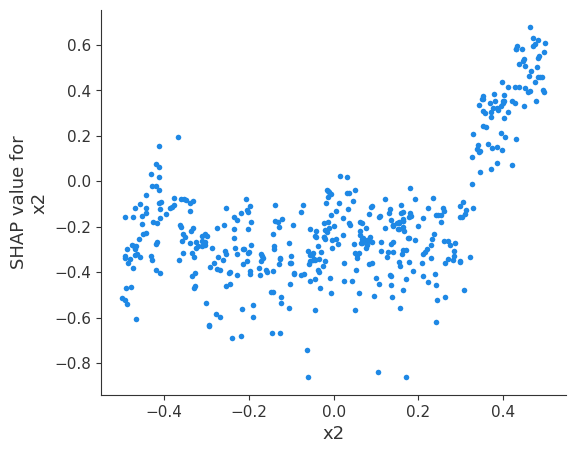

In [12]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, plot_type="bar", plot_size=(16,4))
shap.summary_plot(shap_values, X_val)

top_predictive_features = ["x5", "x1", "x9", "x4", "x10_11_prod", "x8", "City", 
                           "x2_cos_3", "x10", "x11", "x2_cos_2", "x2_cos_1",
                           "x6", "x7", "x2_cos_5", "x2_sin_4", "x2_sin_5", "x2_cos_4",
                           "x2_sin_3", "x2_sin_1", "x2_sin_2", "x2"
                          ]
for feature in top_predictive_features:
    shap.dependence_plot(
        feature,
        shap_values,
        X_val,
        interaction_index=None
    )

# Submission

In [13]:
params = {
    'min_split_loss': 0.0009747428596387491, 
    'min_child_weight': 0.0007252597309807894, 
    'learning_rate': 0.038824907138762486, 
    'reg_alpha': 0.7272645747279445, 
    'reg_lambda': 1.4767087892831248, 
    'colsample_bytree': 0.5912732175055782, 
    'subsample': 0.5168901031281665, 
    'min_child_samples': 142, 
    'huber_slope': 0.35193164590208625
}
params["n_estimators"] = 3000
params["max_depth"]    = 2
params["n_jobs"]       = -1
params["random_state"] = 3126
params["objective"]    = "reg:pseudohubererror"
# params["early_stopping_rounds"] = 100
# params["eval_metric"]  = "mae"
params["verbosity"]    = 0

model = XGBRegressor(**params)
model.fit(X, y, verbose=False)

test_new = make_features(test)
sample_submission.target = model.predict(test_new)
sample_submission.to_csv("submission.csv", index=False)